In [1]:
import cv2
import numpy as np
import pytesseract
from pathlib import Path
import matplotlib.pyplot as plt

# Project root for consistent path handling across notebooks
project_root = Path.cwd().parent
print("Project root:", project_root)

Project root: d:\Projects\ocr-document-understanding


# Day 2 — Preprocessing: Deskew

Detect the tilt angle of a document and rotate it back to horizontal.

**Why deskew first:** it changes the geometry of the image. If we apply 
contrast enhancement or denoising first, the rotation later will resample 
those pixels and partly undo the work. Geometry corrections come before 
pixel-value corrections.

**Method:** find all text pixels, fit the smallest rotated rectangle 
around them, read off its angle, rotate the image by the opposite angle.

Loaded: sroie_05.jpg
Shape: (1646, 544, 3)


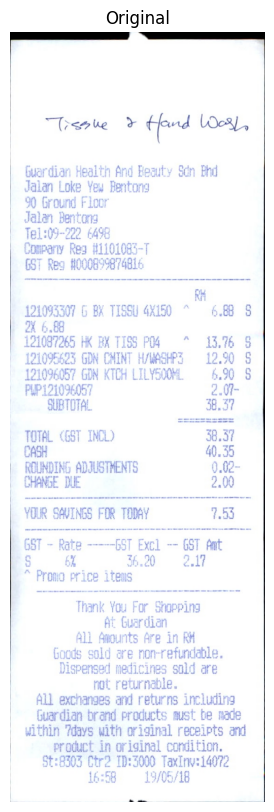

In [14]:
image_path = project_root / "sample_images" / "sroie_05.jpg"
image = cv2.imread(str(image_path))

print("Loaded:", image_path.name)
print("Shape:", image.shape)

plt.figure(figsize=(6, 10))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Original")
plt.show()

Original channels: 3
Gray shape: (1646, 544)


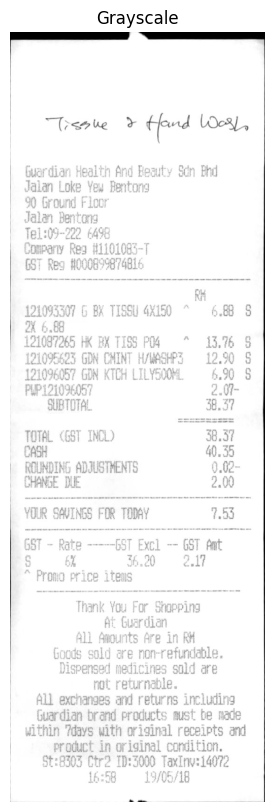

In [15]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

print("Original channels:", image.shape[2])
print("Gray shape:", gray.shape)

plt.figure(figsize=(6, 10))
plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.title("Grayscale")
plt.show()

Cropped shape: (1606, 504)
Otsu threshold: 221.0
Text pixels: 88143
White ratio: 10.9%
Corner values now: 0, 0, 0, 0


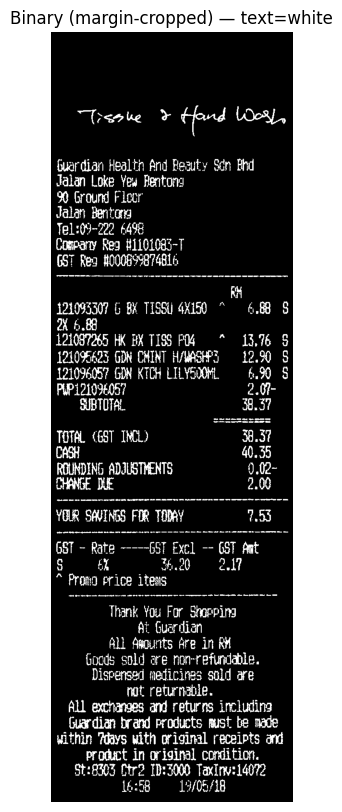

In [20]:
# Crop a small margin to avoid edge artifacts contaminating the point cloud
margin = 20  # pixels to crop from each side
gray_cropped = gray[margin:-margin, margin:-margin]

threshold_used, binary = cv2.threshold(
    gray_cropped, 0, 255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

print(f"Cropped shape: {gray_cropped.shape}")
print(f"Otsu threshold: {threshold_used}")
print(f"Text pixels: {np.count_nonzero(binary)}")
print(f"White ratio: {np.count_nonzero(binary) / binary.size * 100:.1f}%")
print(f"Corner values now: {binary[0,0]}, {binary[0,-1]}, {binary[-1,0]}, {binary[-1,-1]}")

plt.figure(figsize=(6, 10))
plt.imshow(binary, cmap="gray")
plt.axis("off")
plt.title(f"Binary (margin-cropped) — text=white")
plt.show()

In [21]:
coords = cv2.findNonZero(binary)

print("Number of text pixels:", len(coords))
print("Shape of coords:", coords.shape)
print("First 3 points (x, y):", coords[:3].squeeze())

Number of text pixels: 88143
Shape of coords: (88143, 1, 2)
First 3 points (x, y): [[303 153]
 [304 153]
 [305 153]]


In [24]:
rect = cv2.minAreaRect(coords)
(cx, cy), (rect_w, rect_h), raw_angle = rect

print(f"Rect center: ({cx:.1f}, {cy:.1f})")
print(f"Rect size:   {rect_w:.1f} x {rect_h:.1f}")
print(f"Raw angle:   {raw_angle:.2f}°")

# Convert raw angle to a usable rotation correction.
# OpenCV's minAreaRect returns angle in (-90, 90]. Three cases:
#   - Near 0 or near 90/-90: image is axis-aligned, no rotation needed
#   - Between 0 and 45: tilt is the angle itself (rotate by -angle)
#   - Between 45 and 90: rectangle's "long side" is vertical; tilt is (90 - angle)
if raw_angle >= 85 or raw_angle <= -85 or abs(raw_angle) < 0.5:
    skew_angle = 0.0
elif raw_angle > 45:
    skew_angle = raw_angle - 90
elif raw_angle < -45:
    skew_angle = -(90 + raw_angle)
else:
    skew_angle = -raw_angle

print(f"Skew angle to correct: {skew_angle:.2f}°")

Rect center: (251.5, 868.5)
Rect size:   1431.0 x 483.0
Raw angle:   90.00°
Skew angle to correct: 0.00°


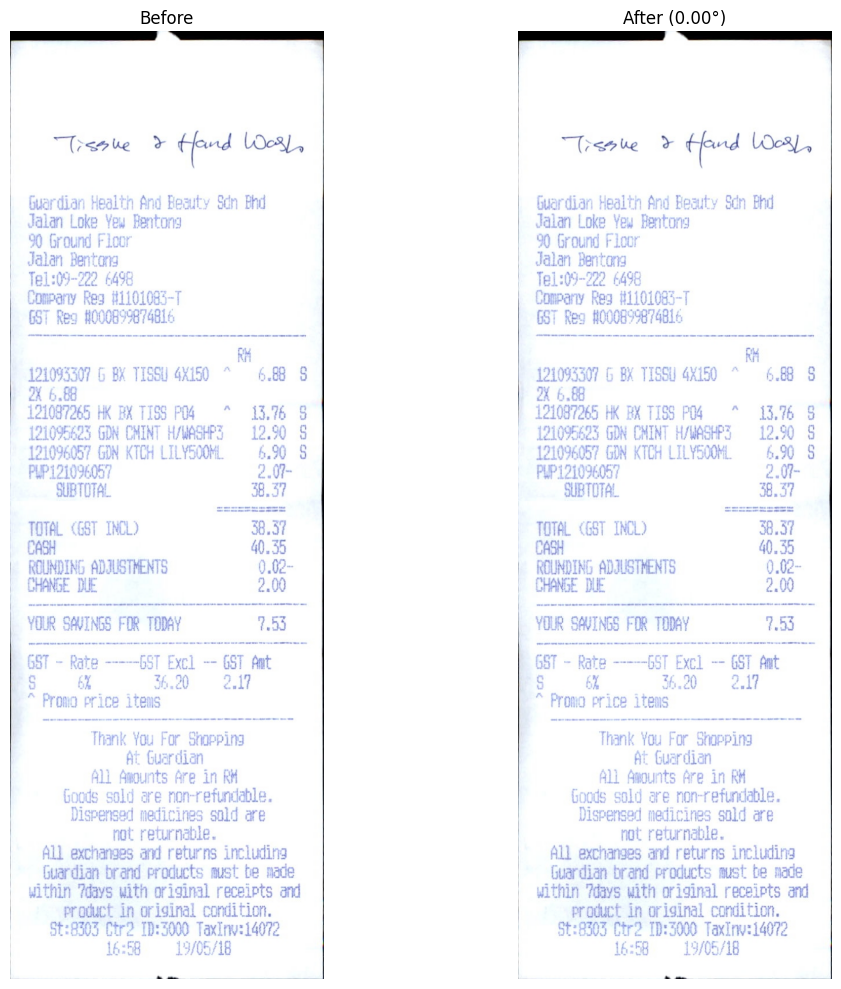

In [26]:
(h, w) = image.shape[:2]
image_center = (w // 2, h // 2)

rotation_matrix = cv2.getRotationMatrix2D(image_center, skew_angle, 1.0)

deskewed = cv2.warpAffine(
    image, rotation_matrix, (w, h),
    flags=cv2.INTER_CUBIC,
    borderMode=cv2.BORDER_REPLICATE,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 10))
axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Before")
axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(deskewed, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"After ({skew_angle:.2f}°)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## CLAHE — Contrast Limited Adaptive Histogram Equalization

Enhance contrast locally to handle uneven lighting. Helps OCR on faded 
receipts, phone photos under mixed lighting, and backlit documents.

**How it works:** divide the image into a grid of tiles, equalize each 
tile's contrast independently, blend smoothly between tiles. Each region 
gets its own contrast boost. The "clip limit" parameter prevents 
over-amplification of noise in flat regions.

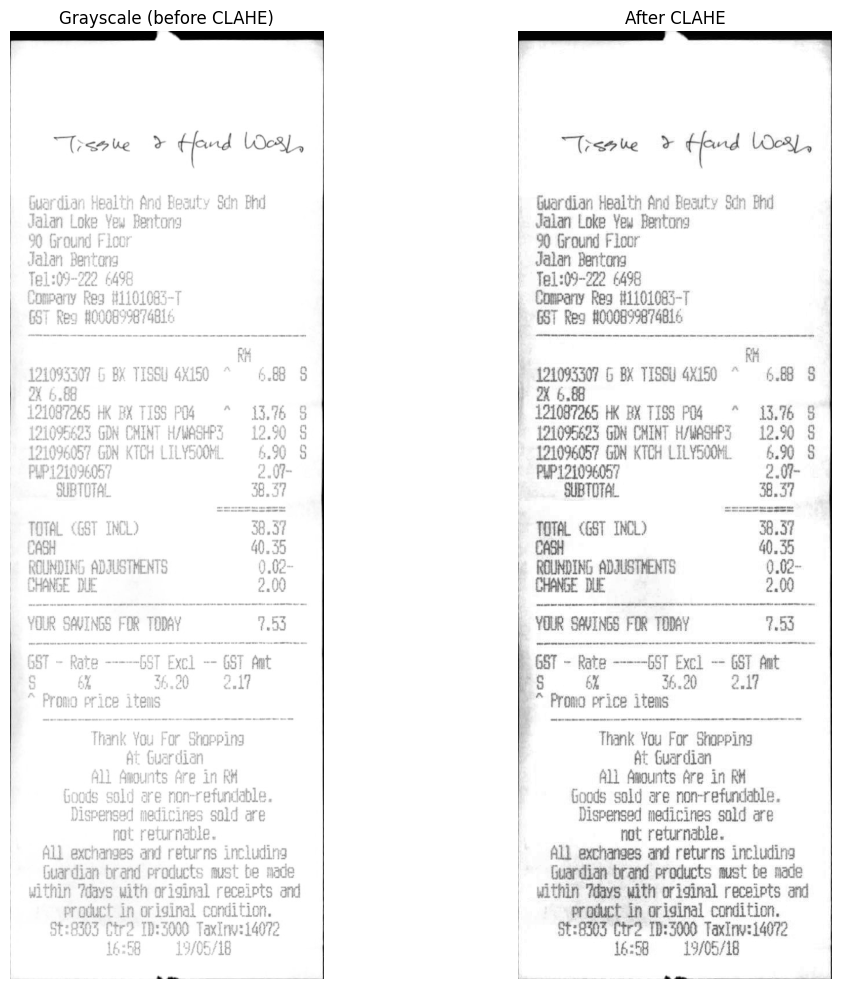

In [33]:
# CLAHE works on a single channel, so use grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
enhanced = clahe.apply(gray)

fig, axes = plt.subplots(1, 2, figsize=(12, 10))
axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Grayscale (before CLAHE)")
axes[0].axis("off")
axes[1].imshow(enhanced, cmap="gray")
axes[1].set_title("After CLAHE")
axes[1].axis("off")
plt.tight_layout()
plt.show()

In [34]:
# Does CLAHE actually help OCR on this image?
def count_confident_words(img, threshold=50):
    """Count words Tesseract detects above a confidence threshold."""
    data = pytesseract.image_to_data(img, output_type=pytesseract.Output.DICT)
    count = 0
    for i in range(len(data["text"])):
        if int(data["conf"][i]) > threshold and data["text"][i].strip() != "":
            count += 1
    return count

original_score = count_confident_words(image)
gray_score = count_confident_words(gray)
enhanced_score = count_confident_words(enhanced)

print(f"Words with conf > 50:")
print(f"  Original (BGR):    {original_score}")
print(f"  Grayscale:         {gray_score}")
print(f"  CLAHE-enhanced:    {enhanced_score}")
print()
print(f"CLAHE vs grayscale: {enhanced_score - gray_score:+d} words")

Words with conf > 50:
  Original (BGR):    78
  Grayscale:         28
  CLAHE-enhanced:    114

CLAHE vs grayscale: +86 words


In [35]:
def apply_clahe(image, clip_limit=2.0, tile_size=(8, 8)):
    """
    Apply CLAHE to enhance local contrast.
    
    Args:
        image: BGR numpy array from cv2.imread.
        clip_limit: contrast amplification cap (1.0-4.0 typical).
        tile_size: grid of tiles for local equalization.
    
    Returns:
        Single-channel (grayscale) numpy array with enhanced contrast.
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_size)
    return clahe.apply(gray)


# Quick verify — should match the Cell 12 result
test_enhanced = apply_clahe(image)
print(f"Output shape: {test_enhanced.shape}")
print(f"Output dtype: {test_enhanced.dtype}")
print(f"Matches manual result: {np.array_equal(test_enhanced, enhanced)}")

Output shape: (1646, 544)
Output dtype: uint8
Matches manual result: True


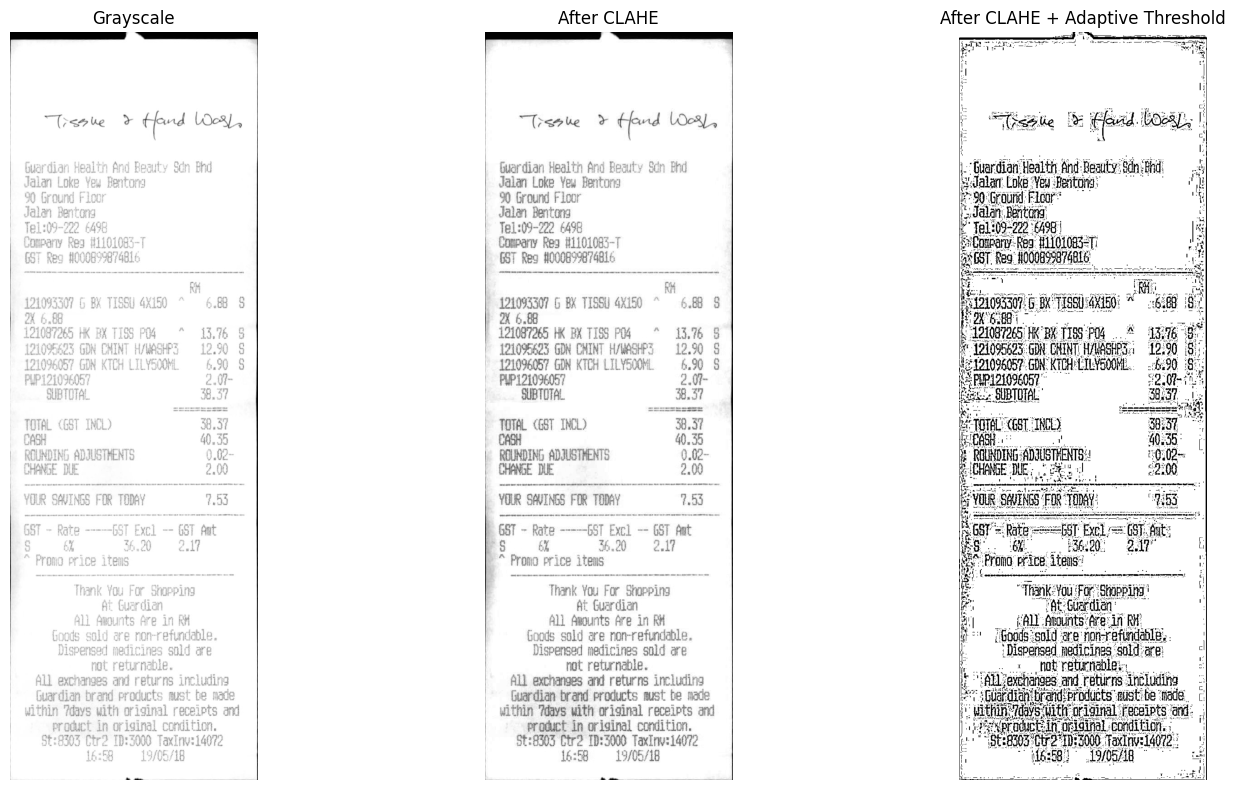

In [36]:
# Adaptive threshold on the CLAHE-enhanced image
adaptive = cv2.adaptiveThreshold(
    enhanced,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    blockSize=11,
    C=2,
)

fig, axes = plt.subplots(1, 3, figsize=(16, 8))
axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Grayscale")
axes[0].axis("off")
axes[1].imshow(enhanced, cmap="gray")
axes[1].set_title("After CLAHE")
axes[1].axis("off")
axes[2].imshow(adaptive, cmap="gray")
axes[2].set_title("After CLAHE + Adaptive Threshold")
axes[2].axis("off")
plt.tight_layout()
plt.show()

In [37]:
adaptive_score = count_confident_words(adaptive)

print(f"Words with conf > 50:")
print(f"  Original (BGR):           {original_score}")
print(f"  CLAHE only:               {enhanced_score}")
print(f"  CLAHE + Adaptive thresh:  {adaptive_score}")
print()
print(f"Adaptive vs CLAHE alone: {adaptive_score - enhanced_score:+d} words")
print(f"Adaptive vs Original:    {adaptive_score - original_score:+d} words")

Words with conf > 50:
  Original (BGR):           78
  CLAHE only:               114
  CLAHE + Adaptive thresh:  0

Adaptive vs CLAHE alone: -114 words
Adaptive vs Original:    -78 words


Adaptive image stats:
  Min: 0, Max: 255
  White pixels: 761499
  Black pixels: 133925
  White ratio: 85.0%


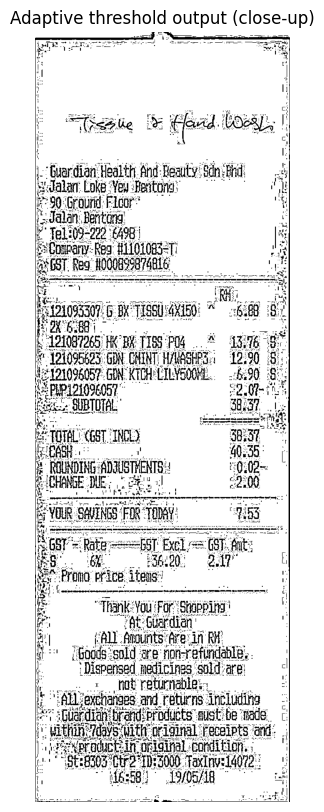

In [38]:
print(f"Adaptive image stats:")
print(f"  Min: {adaptive.min()}, Max: {adaptive.max()}")
print(f"  White pixels: {np.count_nonzero(adaptive)}")
print(f"  Black pixels: {adaptive.size - np.count_nonzero(adaptive)}")
print(f"  White ratio: {np.count_nonzero(adaptive) / adaptive.size * 100:.1f}%")

plt.figure(figsize=(6, 10))
plt.imshow(adaptive, cmap="gray")
plt.axis("off")
plt.title("Adaptive threshold output (close-up)")
plt.show()

In [39]:
# What is Tesseract actually seeing?
data = pytesseract.image_to_data(adaptive, output_type=pytesseract.Output.DICT)
confs = [int(c) for c in data["conf"] if int(c) >= 0]
texts = [t for t, c in zip(data["text"], data["conf"]) if int(c) >= 0 and t.strip()]

print(f"Total items detected: {len(confs)}")
print(f"Items with text: {len(texts)}")
print(f"Conf > 50: {sum(1 for c in confs if c > 50)}")
print(f"Conf > 30: {sum(1 for c in confs if c > 30)}")
print(f"Conf > 0:  {sum(1 for c in confs if c > 0)}")
print(f"\nFirst 10 detected texts with their conf:")
count = 0
for i in range(len(data["text"])):
    if int(data["conf"][i]) >= 0 and data["text"][i].strip():
        print(f"  conf={data['conf'][i]:>3}  text='{data['text'][i]}'")
        count += 1
        if count >= 10:
            break

Total items detected: 4
Items with text: 0
Conf > 50: 4
Conf > 30: 4
Conf > 0:  4

First 10 detected texts with their conf:


## Key Finding: Tesseract vs Pre-binarized Images

Tesseract performs its own internal binarization. Feeding it an 
already-thresholded binary image can *break* its text detection — 
it detected 0 readable words on our adaptive threshold output vs 
114 on CLAHE-enhanced grayscale.

**Pipeline decision:** 
- For Tesseract: feed CLAHE-enhanced grayscale. Do NOT pre-threshold.
- Adaptive thresholding may still help PaddleOCR (to be tested in Stage 3).
- Keep the adaptive threshold function available but don't use it as 
  default Tesseract preprocessing.

In [40]:
def apply_adaptive_threshold(image_gray, block_size=11, C=2):
    """
    Adaptive Gaussian thresholding on a grayscale image.
    
    Args:
        image_gray: single-channel numpy array (e.g. output of apply_clahe).
        block_size: neighborhood size (must be odd). Larger = smoother.
        C: constant subtracted from local threshold. Higher = more aggressive.
    
    Returns:
        Binary single-channel image (text=black, background=white).
    
    WARNING: do not feed the output directly to Tesseract — it performs
    its own binarization and conflicts with pre-thresholded input.
    May be useful for PaddleOCR or layout analysis.
    """
    return cv2.adaptiveThreshold(
        image_gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        blockSize=block_size,
        C=C,
    )


test_at = apply_adaptive_threshold(enhanced)
print(f"Output shape: {test_at.shape}, dtype: {test_at.dtype}")
print(f"Matches Cell 15 result: {np.array_equal(test_at, adaptive)}")

Output shape: (1646, 544), dtype: uint8
Matches Cell 15 result: True


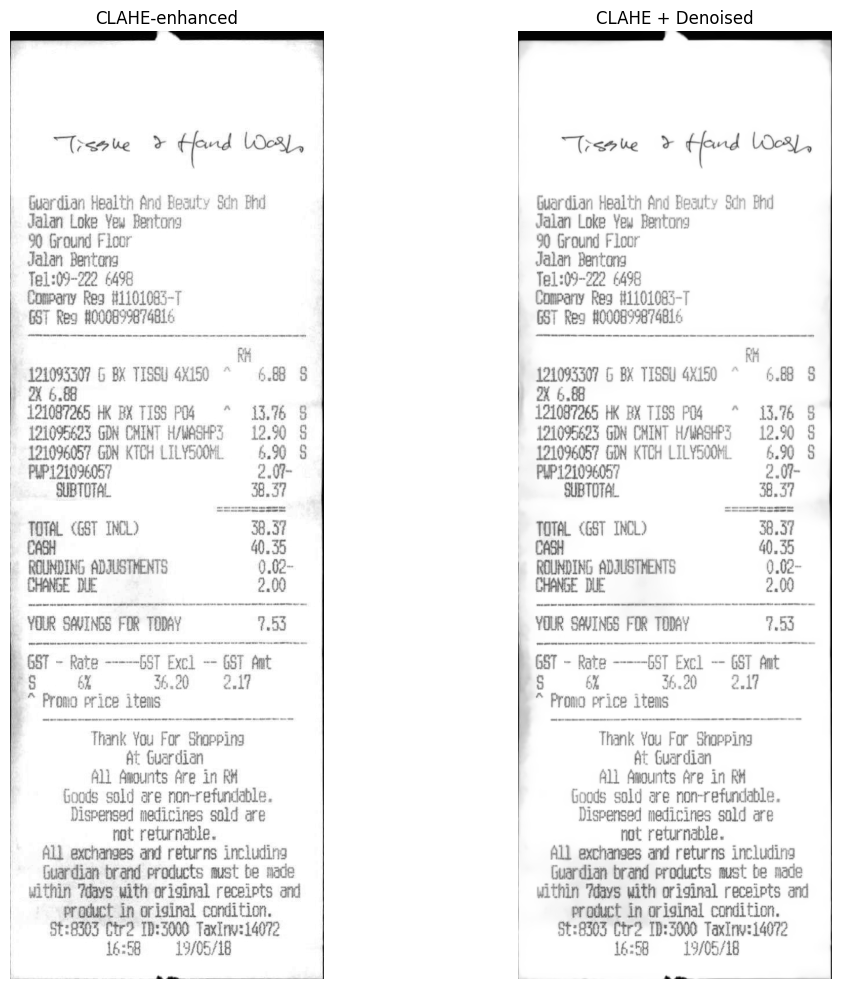

In [41]:
# fastNlMeansDenoising is OpenCV's non-local means denoiser for grayscale images.
# It's slow compared to a Gaussian blur but much better at preserving edges (text).
denoised = cv2.fastNlMeansDenoising(enhanced, h=10, templateWindowSize=7, searchWindowSize=21)

fig, axes = plt.subplots(1, 2, figsize=(12, 10))
axes[0].imshow(enhanced, cmap="gray")
axes[0].set_title("CLAHE-enhanced")
axes[0].axis("off")
axes[1].imshow(denoised, cmap="gray")
axes[1].set_title("CLAHE + Denoised")
axes[1].axis("off")
plt.tight_layout()
plt.show()

In [42]:
denoised_score = count_confident_words(denoised)

print(f"Words with conf > 50:")
print(f"  Original (BGR):      {original_score}")
print(f"  CLAHE only:          {enhanced_score}")
print(f"  CLAHE + Denoised:    {denoised_score}")
print()
print(f"Denoised vs CLAHE: {denoised_score - enhanced_score:+d} words")

Words with conf > 50:
  Original (BGR):      78
  CLAHE only:          114
  CLAHE + Denoised:    121

Denoised vs CLAHE: +7 words


In [43]:
def apply_denoise(image_gray, strength=10):
    """
    Non-local means denoising on a grayscale image.
    
    Args:
        image_gray: single-channel numpy array.
        strength: filter strength (3-20 typical). Higher = more smoothing.
    
    Returns:
        Denoised single-channel numpy array.
    """
    return cv2.fastNlMeansDenoising(
        image_gray, h=strength,
        templateWindowSize=7,
        searchWindowSize=21,
    )


test_dn = apply_denoise(enhanced)
print(f"Matches Cell 19 result: {np.array_equal(test_dn, denoised)}")


Matches Cell 19 result: True


In [44]:
def preprocess(image, clip_limit=2.0, tile_size=(8, 8), denoise_strength=10):
    """
    Full preprocessing pipeline for document OCR.
    
    Steps:
        1. CLAHE (contrast enhancement)
        2. Denoising (noise removal while preserving edges)
    
    Args:
        image: BGR numpy array from cv2.imread.
        clip_limit: CLAHE contrast cap.
        tile_size: CLAHE tile grid.
        denoise_strength: denoising filter strength (0 to skip denoising).
    
    Returns:
        Preprocessed single-channel (grayscale) numpy array.
    """
    enhanced = apply_clahe(image, clip_limit, tile_size)
    
    if denoise_strength > 0:
        enhanced = apply_denoise(enhanced, denoise_strength)
    
    return enhanced


# Full pipeline test — compare all stages
preprocessed = preprocess(image)
preprocessed_score = count_confident_words(preprocessed)

print(f"Summary — words with conf > 50:")
print(f"  Original (no preprocessing):  {original_score}")
print(f"  Full pipeline (CLAHE+denoise): {preprocessed_score}")
print(f"  Improvement: {preprocessed_score - original_score:+d} words ({(preprocessed_score - original_score) / original_score * 100:+.0f}%)")

Summary — words with conf > 50:
  Original (no preprocessing):  78
  Full pipeline (CLAHE+denoise): 121
  Improvement: +43 words (+55%)


## Day 2 Preprocessing — Summary

**What works:**
- CLAHE: +36 words over raw input (78 → 114)
- CLAHE + Denoise: +43 words over raw input (78 → 121, +55%)
- Full pipeline: `preprocess(image)` returns a clean grayscale ready for OCR

**What didn't work:**
- Deskew via minAreaRect: fails when text fills the frame (common in receipts). 
  Documented, not shipped. Hough-based alternative deferred.
- Adaptive threshold + Tesseract: Tesseract's internal binarization conflicts 
  with pre-thresholded input. 0 words detected. Function kept for potential 
  PaddleOCR use.

**Key finding:**
- Plain grayscale (28 words) is WORSE than raw BGR (78 words) for Tesseract. 
  Never feed plain grayscale to Tesseract — either use color or enhance first.

**Next:** port functions to `src/preprocessing.py`, then move to Stage 3 (OCR).

In [46]:
import sys
sys.path.insert(0, str(project_root))

import importlib
import src.preprocessing
importlib.reload(src.preprocessing)

from src.preprocessing import preprocess as preprocess_imported

result_imported = preprocess_imported(image)
print(f"Imported result matches notebook result: {np.array_equal(result_imported, preprocessed)}")
print(f"Imported score: {count_confident_words(result_imported)} words (should be {preprocessed_score})")

Imported result matches notebook result: True
Imported score: 121 words (should be 121)
